# What Drives the Price of a Car?

## 1. Business Understanding

* The dealership wants to know which car features drive price.
* This helps them decide what to buy, what to pay and how to price cars.
* This is a **regression** problem.
* **Target:** `price` (USD).
* **Features:** car details in each listing, such as year, mileage, manufacturer, condition, fuel type and body type.

## 2. Data Understanding

* Check columns, missing values, outliers and duplicates.
* Plot price against the main features.

In [1]:
# Core libraries, aliased by convention
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

# Lasso at very small alphas can emit convergence warnings; results are still usable
warnings.filterwarnings('ignore', category=ConvergenceWarning)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', '{:,.2f}'.format)
RANDOM_STATE = 42

In [2]:
# Load the raw data
vehicles_raw = pd.read_csv('data/vehicles.csv')
print(f'Rows: {vehicles_raw.shape[0]:,}  Columns: {vehicles_raw.shape[1]}')
vehicles_raw.sample(5, random_state=42)

Rows: 426,880  Columns: 18


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
100905,7315883828,lakeland,36990,"2,017.00",ford,f150 super cab lariat,good,6 cylinders,gas,"38,094.00",clean,other,1FTFX1EG9HKD14814,4wd,NaN,pickup,white,fl
143835,7314599643,"quad cities, IA/IL",27995,"2,006.00",chevrolet,corvette,good,8 cylinders,gas,NaN,clean,manual,NaN,rwd,NaN,convertible,black,il
20235,7308399808,little rock,78423,"2,015.00",chevrolet,corvette,NaN,8 cylinders,gas,"30,200.00",clean,automatic,NaN,rwd,NaN,convertible,NaN,ar
300734,7312663807,northern panhandle,14000,"2,013.00",bmw,328i,NaN,NaN,gas,"92,965.00",clean,automatic,NaN,NaN,NaN,NaN,NaN,oh
316249,7315368523,eugene,676,"2,019.00",chevrolet,suburban ls,NaN,8 cylinders,other,"47,105.00",clean,automatic,1GNSKGKC7KR124145,NaN,NaN,NaN,black,or


In [3]:
# Column types, non-null counts and share of missing values
overview = pd.DataFrame({
    'dtype': vehicles_raw.dtypes.astype(str),
    'non_null': vehicles_raw.notna().sum(),
    'pct_missing': vehicles_raw.isna().mean() * 100,
    'n_unique': vehicles_raw.nunique(),
}).sort_values('pct_missing', ascending=False)
overview

,dtype,non_null,pct_missing,n_unique
size,str,120519,71.77,4
cylinders,str,249202,41.62,8
condition,str,252776,40.79,6
VIN,str,265838,37.73,118246
drive,str,296313,30.59,3
paint_color,str,296677,30.50,12
type,str,334022,21.75,13
manufacturer,str,409234,4.13,42
title_status,str,418638,1.93,6
model,str,421603,1.24,29649


**Missing data:**

* `size` is missing in about 72% of rows, so I drop it (it also overlaps with `type`).
* `condition`, `cylinders`, `VIN`, `drive` and `paint_color` are missing in 30–42% of rows.
* Dropping those rows would lose most of the data, so I fill missing categories with `unknown`.

In [4]:
# Summary statistics of the numeric columns
vehicles_raw[['price', 'year', 'odometer']].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,price,year,odometer
count,"426,880.00","425,675.00","422,480.00"
mean,"75,199.03","2,011.24","98,043.33"
std,"12,182,282.17",9.45,"213,881.50"
min,0.00,"1,900.00",0.00
1%,0.00,"1,967.00",2.00
5%,0.00,"1,998.00","6,318.00"
25%,"5,900.00","2,008.00","37,704.00"
50%,"13,950.00","2,013.00","85,548.00"
75%,"26,485.75","2,017.00","133,542.50"
95%,"44,500.00","2,020.00","204,000.00"


In [5]:
# How many listings have implausible prices or odometer readings?
quality_checks = pd.Series({
    'price == 0': (vehicles_raw['price'] == 0).sum(),
    'price < $1,000': (vehicles_raw['price'] < 1_000).sum(),
    'price > $100,000': (vehicles_raw['price'] > 100_000).sum(),
    'year < 1995': (vehicles_raw['year'] < 1995).sum(),
    'model year 2022 (scrape year)': (vehicles_raw['year'] == 2022).sum(),
    'odometer > 400,000': (vehicles_raw['odometer'] > 400_000).sum(),
    'duplicate listings (ignoring id/region)': vehicles_raw.drop(columns=['id', 'region']).duplicated().sum(),
}, name='count')
quality_checks.to_frame()

,count
price == 0,32895
"price < $1,000",46315
"price > $100,000",655
year < 1995,15896
model year 2022 (scrape year),133
"odometer > 400,000",1702
duplicate listings (ignoring id/region),127371


* Median price is \$13,950. The mean (\$75K) is skewed by outliers.
* Prices range from \$0 to \$3.7B, with many \$0/\$1 placeholders.
* Odometer goes up to 10M miles, and years go back to 1900.
* 2022 listings look like down-payment ads.
* Over 100K duplicate listings across regions.
* `model` and `VIN` can't be used directly, and `region` overlaps with `state`.

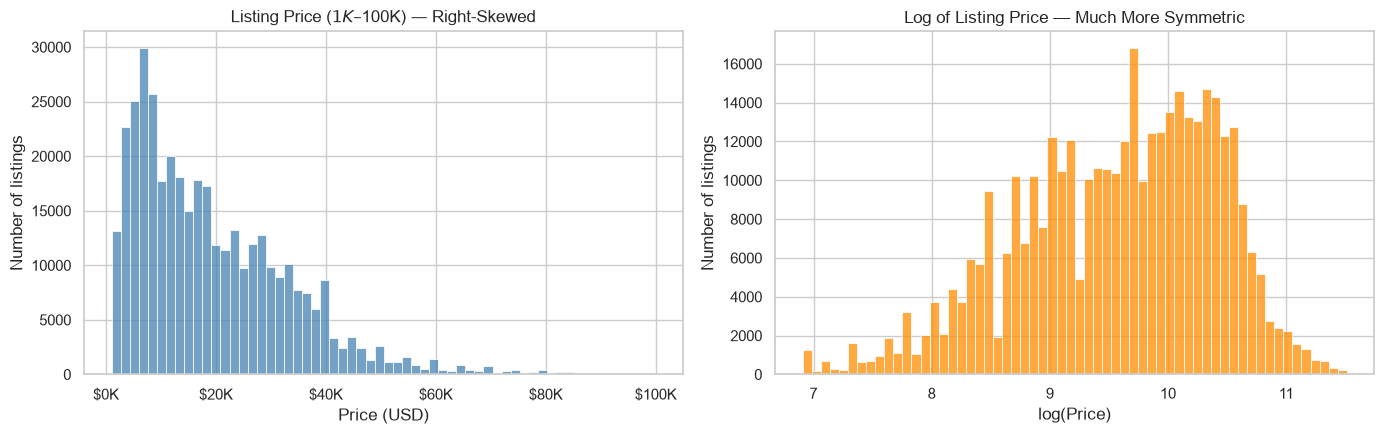

In [6]:
# Price distribution on raw and log scale for a plausible price range
plausible_price = vehicles_raw.loc[vehicles_raw['price'].between(1_000, 100_000), 'price']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(plausible_price, bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Listing Price ($1K–$100K) — Right-Skewed')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Number of listings')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))

sns.histplot(np.log(plausible_price), bins=60, ax=axes[1], color='darkorange')
axes[1].set_title('Log of Listing Price — Much More Symmetric')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Number of listings')
plt.tight_layout()
plt.show()

* Raw price is very right-skewed, and log price is close to normal.
* I model `log(price)`, which works better for linear regression.
* Coefficients can then be read as percent changes in price.

## 3. Data Preparation

* Drop `id`, `VIN`, `region`, `model` and `size`.
* Remove duplicates.
* Keep prices of \$1,000–\$100,000, model years 1995–2021 and 100–400,000 miles.
* Create `age` = 2022 − `year`.
* Fill missing categories with `unknown`.
* Create the target `log_price`.
* Scaling, one-hot encoding and polynomial features run inside a `Pipeline`, so they only fit on training folds.

In [7]:
CATEGORICAL_FEATURES = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
                        'transmission', 'drive', 'type', 'paint_color', 'state']
NUMERIC_FEATURES = ['age', 'odometer']

vehicles = (
    vehicles_raw
    .drop(columns=['id', 'VIN', 'region', 'model', 'size'])
    .drop_duplicates()
    .dropna(subset=['year', 'odometer'])
    .query('1000 <= price <= 100000 and 1995 <= year <= 2021 and 100 <= odometer <= 400000')
    .assign(age=lambda d: (2022 - d['year']).astype(int))
    .drop(columns='year')
    .reset_index(drop=True)
)
vehicles[CATEGORICAL_FEATURES] = vehicles[CATEGORICAL_FEATURES].fillna('unknown')
vehicles['log_price'] = np.log(vehicles['price'])

print(f'Rows kept: {len(vehicles):,} of {len(vehicles_raw):,} ({len(vehicles) / len(vehicles_raw):.0%})')
print(f'Remaining missing values: {vehicles.isna().sum().sum()}')
vehicles.head()

Rows kept: 248,919 of 426,880 (58%)
Remaining missing values: 0


,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,age,log_price
0,33590,gmc,good,8 cylinders,gas,"57,923.00",clean,other,unknown,pickup,white,al,8,10.42
1,22590,chevrolet,good,8 cylinders,gas,"71,229.00",clean,other,unknown,pickup,blue,al,12,10.03
2,39590,chevrolet,good,8 cylinders,gas,"19,160.00",clean,other,unknown,pickup,red,al,2,10.59
3,30990,toyota,good,8 cylinders,gas,"41,124.00",clean,other,unknown,pickup,red,al,5,10.34
4,15000,ford,excellent,6 cylinders,gas,"128,000.00",clean,automatic,rwd,truck,black,al,9,9.62


### Exploring the Cleaned Data

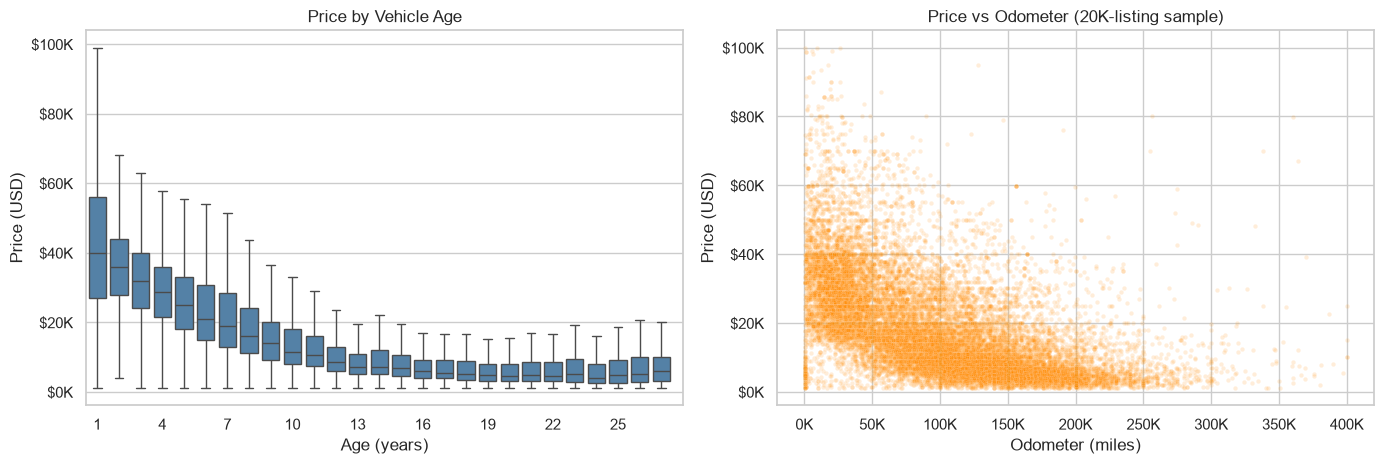

In [8]:
# Continuous features vs price: age and mileage (sample for plot readability)
plot_sample = vehicles.sample(20_000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.boxplot(data=vehicles, x='age', y='price', ax=axes[0], color='steelblue', showfliers=False)
axes[0].set_title('Price by Vehicle Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Price (USD)')
axes[0].set_xticks(range(0, 28, 3))

sns.scatterplot(data=plot_sample, x='odometer', y='price', alpha=0.15, s=10, ax=axes[1], color='darkorange')
axes[1].set_title('Price vs Odometer (20K-listing sample)')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Price (USD)')

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K'))
plt.tight_layout()
plt.show()

* Price goes down as age and mileage go up.
* The drop levels off for older cars, so the models try polynomial terms for age and mileage.

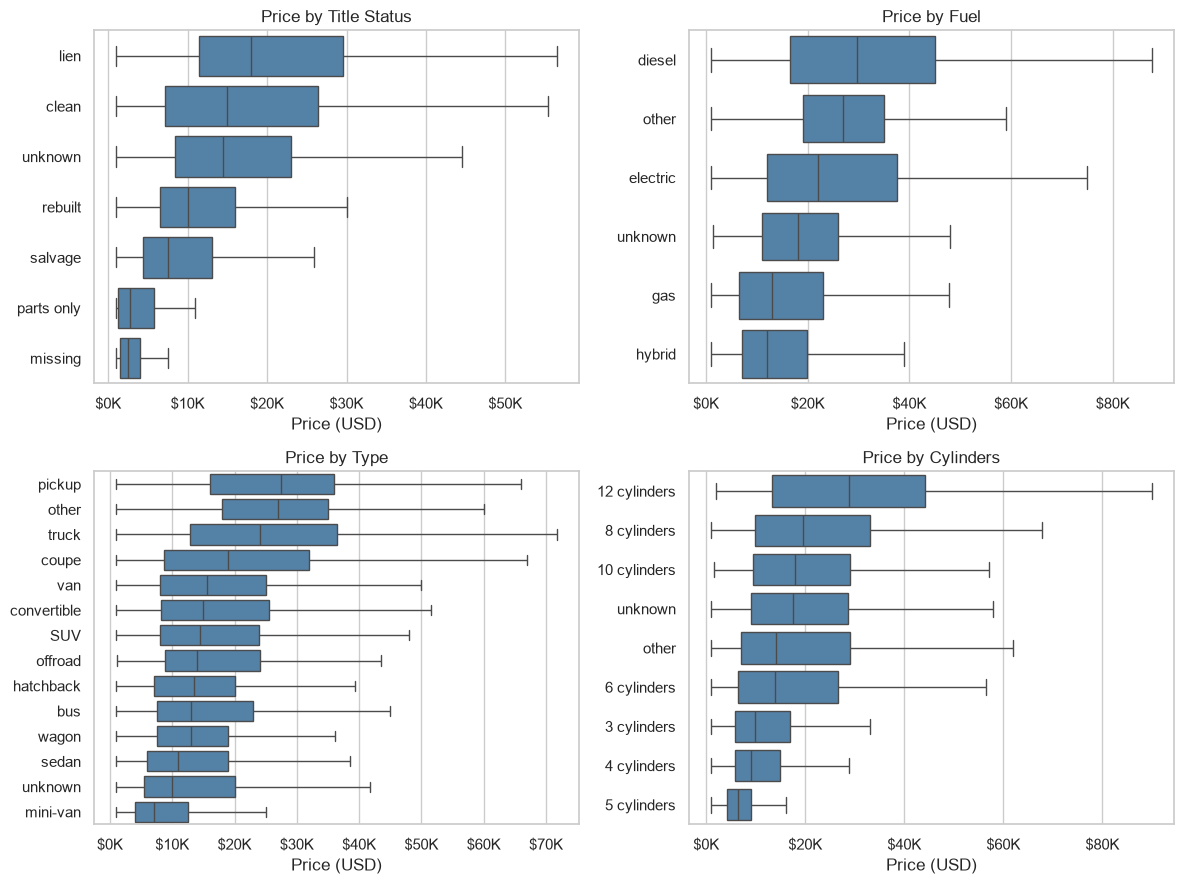

In [9]:
# Categorical features vs price: median price by category, ordered by median
def plot_price_by_category(data, columns, n_cols=3, top_n=15):
    """Draw one boxplot of price per categorical column, categories ordered by median price."""
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
    for ax, col in zip(axes.flat, columns):
        top_levels = data[col].value_counts().head(top_n).index
        subset = data[data[col].isin(top_levels)]
        order = subset.groupby(col)['price'].median().sort_values(ascending=False).index
        sns.boxplot(data=subset, y=col, x='price', order=order, ax=ax, color='steelblue', showfliers=False)
        ax.set_title(f'Price by {col.replace("_", " ").title()}')
        ax.set_xlabel('Price (USD)')
        ax.set_ylabel('')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
    for ax in axes.flat[len(columns):]:
        ax.set_visible(False)
    plt.tight_layout()
    return fig

fig = plot_price_by_category(vehicles, ['title_status', 'fuel', 'type', 'cylinders'], n_cols=2)
plt.show()

**First observations** (not yet controlling for other features):

* Clean titles sell for more than rebuilt, salvage or missing titles.
* Diesel has the highest median price (mostly trucks).
* Pickups and trucks are the most expensive body types, and minivans and sedans are among the cheapest.
* 8-cylinder cars cost more than 4-cylinder cars.
* Many features are related (diesel vehicles are usually trucks), so I use regression to separate their effects.

### Train / Test Split

* 20% of the data is held out as a test set, used once at the end.
* All tuning uses cross-validation on the training set.

In [10]:
X = vehicles[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = vehicles['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'Training rows: {len(X_train):,}   Test rows: {len(X_test):,}')

Training rows: 199,135   Test rows: 49,784


## 4. Modeling

### Evaluation metric

* **RMSE on log(price)** is used to choose between models.
* On the log scale it measures percent error. An RMSE of 0.40 means predictions are off by a factor of about e^0.40 ≈ 1.5.
* Percent error fits car prices, because a \$2,000 miss matters more on a \$5,000 car than on a \$60,000 car.
* It penalizes big misses more, and those cost a dealer the most.
* I also report **R²** and **mean absolute error in dollars**, which is easier to explain.

### Models

* Numeric features get polynomial terms and scaling, and categorical features are one-hot encoded.
* All models are tuned with grid search and 5-fold cross-validation.
* Baseline (predict the mean)
* Simple Linear Regression (age and mileage only)
* Multiple Linear Regression (all features)
* Ridge
* Lasso
* PCA + Linear Regression

In [11]:
def make_preprocessor(numeric_features=NUMERIC_FEATURES, categorical_features=CATEGORICAL_FEATURES, sparse=True):
    """Polynomial + scaling for numeric columns, one-hot encoding for categorical columns."""
    numeric_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=1, include_bias=False)),
        ('scale', StandardScaler()),
    ])
    transformers = [('num', numeric_pipe, numeric_features)]
    if categorical_features:
        transformers.append(('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=50,
                                                  sparse_output=sparse), categorical_features))
    return ColumnTransformer(transformers)


cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}  # model name -> fitted GridSearchCV


def run_grid_search(name, pipeline, param_grid, X_data=X_train):
    """Fit a cross-validated grid search, store it and print the best CV RMSE."""
    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_root_mean_squared_error',
                          n_jobs=-1, return_train_score=True)
    search.fit(X_data, y_train)
    cv_results[name] = search
    print(f'{name:<28} best CV RMSE = {-search.best_score_:.4f}   best params = {search.best_params_}')
    return search

In [12]:
# 1. Baseline: predict the mean
baseline = run_grid_search('Baseline (mean)', Pipeline([('model', DummyRegressor())]), {})

# 2. Simple linear regression on the two numeric drivers only
simple_lr = run_grid_search(
    'Linear Regression (age+miles)',
    Pipeline([('pre', make_preprocessor(categorical_features=[])), ('model', LinearRegression())]),
    {'pre__num__poly__degree': [1, 2, 3]},
    X_data=X_train[NUMERIC_FEATURES],
)

Baseline (mean)              best CV RMSE = 0.8509   best params = {}


Linear Regression (age+miles) best CV RMSE = 0.5734   best params = {'pre__num__poly__degree': 3}


In [13]:
# 3. Multiple linear regression on all features
full_lr = run_grid_search(
    'Linear Regression (all)',
    Pipeline([('pre', make_preprocessor()), ('model', LinearRegression())]),
    {'pre__num__poly__degree': [1, 2, 3]},
)

# 4. Ridge regression: tune polynomial degree and regularization strength together
ridge = run_grid_search(
    'Ridge',
    Pipeline([('pre', make_preprocessor()), ('model', Ridge())]),
    {'pre__num__poly__degree': [1, 2, 3], 'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
)

Linear Regression (all)      best CV RMSE = 0.4009   best params = {'pre__num__poly__degree': 3}


Ridge                        best CV RMSE = 0.4009   best params = {'model__alpha': 1, 'pre__num__poly__degree': 3}


In [14]:
# 5. Lasso regression: tune regularization strength (degree fixed at 3, the best degree above)
lasso = run_grid_search(
    'Lasso',
    Pipeline([('pre', make_preprocessor()), ('model', Lasso(max_iter=5000))]),
    {'pre__num__poly__degree': [3], 'model__alpha': [0.0001, 0.001, 0.01, 0.1]},
)

Lasso                        best CV RMSE = 0.4013   best params = {'model__alpha': 0.0001, 'pre__num__poly__degree': 3}


### PCA + Linear Regression

* PCA reduces the features before fitting a linear regression.
* The scree plot shows how much variance each component explains.

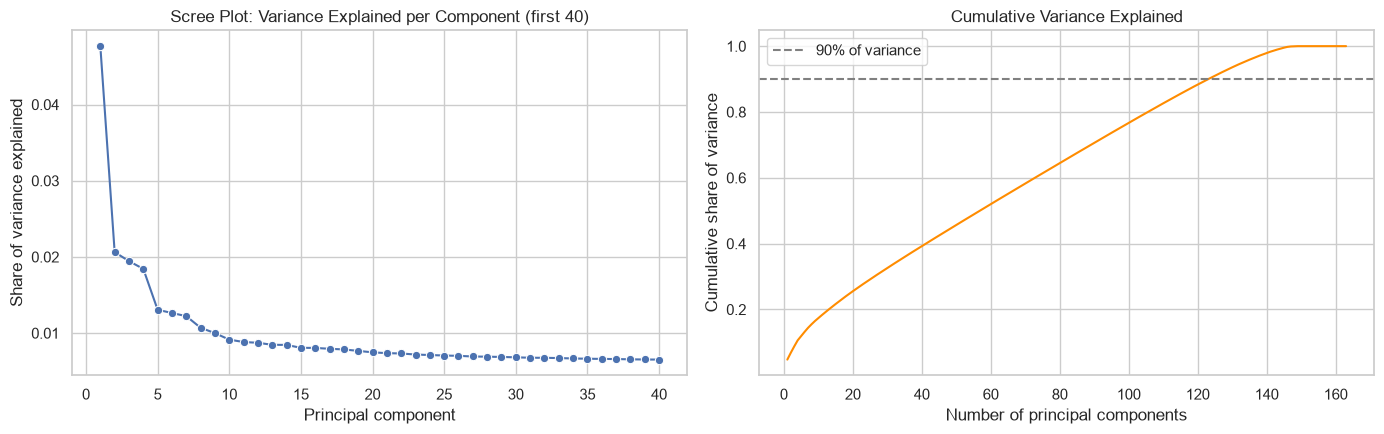

Components needed for 90% of variance: 124 of 163


In [15]:
# Encode + standardize the training features (dense so PCA can use them), then fit a full PCA
pca_preprocessor = make_preprocessor(sparse=False).set_params(num__poly__degree=3)
X_train_scaled = StandardScaler().fit_transform(pca_preprocessor.fit_transform(X_train))
pca_full = PCA().fit(X_train_scaled)
explained = pd.DataFrame({
    'component': np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    'explained': pca_full.explained_variance_ratio_,
    'cumulative': pca_full.explained_variance_ratio_.cumsum(),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=explained.head(40), x='component', y='explained', marker='o', ax=axes[0])
axes[0].set_title('Scree Plot: Variance Explained per Component (first 40)')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Share of variance explained')

sns.lineplot(data=explained, x='component', y='cumulative', ax=axes[1], color='darkorange')
axes[1].axhline(0.9, color='grey', linestyle='--', label='90% of variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of principal components')
axes[1].set_ylabel('Cumulative share of variance')
axes[1].legend()
plt.tight_layout()
plt.show()

n_encoded = X_train_scaled.shape[1]
print(f'Components needed for 90% of variance: {(explained["cumulative"] < 0.9).sum() + 1} of {n_encoded}')

In [16]:
# 6. PCA + linear regression: grid search over the number of principal components
pcr = GridSearchCV(
    Pipeline([('pre', make_preprocessor(sparse=False).set_params(num__poly__degree=3)),
              ('scale', StandardScaler()), ('pca', PCA(random_state=RANDOM_STATE)), ('model', LinearRegression())]),
    {'pca__n_components': [5, 10, 25, 50, 75, 100, 125, n_encoded]},
    cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1,
).fit(X_train, y_train)
cv_results['PCA + Linear Regression'] = pcr
print(f'PCA + Linear Regression      best CV RMSE = {-pcr.best_score_:.4f}   best params = {pcr.best_params_}')


PCA + Linear Regression      best CV RMSE = 0.4009   best params = {'pca__n_components': 163}


* The scree plot has no clear elbow.
* About 124 of 163 components are needed for 90% of the variance, which is normal for one-hot encoded data.
* The best CV RMSE (0.40) needs all 163 components, which is the same as regular linear regression.
* PCA components can't be read as car features, so I don't use this model.

## 5. Evaluation

### Comparing models

* The table shows each model's cross-validated RMSE and one final test-set score.

In [17]:
def evaluate(name, search):
    """Score a fitted search on the held-out test set."""
    X_eval = X_test[NUMERIC_FEATURES] if 'age+miles' in name else X_test
    log_pred = search.predict(X_eval)
    return {
        'model': name,
        'cv_rmse_log': -search.best_score_,
        'test_rmse_log': root_mean_squared_error(y_test, log_pred),
        'test_r2_log': r2_score(y_test, log_pred),
        'test_mae_usd': mean_absolute_error(np.exp(y_test), np.exp(log_pred)),
    }

comparison = pd.DataFrame([evaluate(name, search) for name, search in cv_results.items()]).set_index('model')
comparison.sort_values('cv_rmse_log').style.format({'cv_rmse_log': '{:.4f}', 'test_rmse_log': '{:.4f}',
                                                    'test_r2_log': '{:.3f}', 'test_mae_usd': '${:,.0f}'})

,cv_rmse_log,test_rmse_log,test_r2_log,test_mae_usd
model,,,,
PCA + Linear Regression,0.4009,0.4026,0.777,"$4,501"
Linear Regression (all),0.4009,0.4026,0.777,"$4,501"
Ridge,0.4009,0.4026,0.777,"$4,501"
Lasso,0.4013,0.4031,0.776,"$4,498"
Linear Regression (age+miles),0.5734,0.5727,0.548,"$6,869"
Baseline (mean),0.8509,0.8517,-0.000,"$10,664"


**What the metric means:**

* All full-feature models beat the baseline by a lot. CV RMSE goes from 0.85 (baseline) to 0.57 (age and mileage) to 0.40 (all features).
* An RMSE of 0.40 means a typical prediction is within about ±40–50% of the price.
* The average test error is about \$4,500, compared with \$10,600 for the baseline.
* R² is 0.78, so the model explains about 78% of the variation in log price.
* Test and CV scores are almost the same (0.403 vs 0.401), so there's no overfitting.
* Linear Regression, Ridge, Lasso and PCA (all components) score about the same.

**Chosen model: Ridge (alpha = 1, cubic terms for age and mileage):**

* It ties for the best score.
* Its coefficients map straight to the features.
* The small penalty keeps coefficients for rare categories (like uncommon brands) more stable.

### What drives price? Interpreting the coefficients

* The target is log(price), so a coefficient difference *b* means a **(e^b − 1) × 100%** price difference, all else equal.
* Each category is compared to the most common one (for example, condition vs "good", fuel vs "gas" and manufacturer vs "ford").

In [18]:
# Use the selected Ridge model
best_model = ridge.best_estimator_

# Extract Ridge coefficients with readable feature names
feature_names = best_model.named_steps['pre'].get_feature_names_out()
coefs = pd.Series(best_model.named_steps['model'].coef_, index=feature_names)


def most_common_known(feature):
    """Most frequent level of a feature, ignoring the 'unknown' placeholder."""
    return X_train.loc[X_train[feature] != 'unknown', feature].mode()[0]


def category_effects(feature, coef_series=coefs):
    """Percent price difference of each level vs the most common known level, holding other features fixed."""
    reference = most_common_known(feature)
    prefix = f'cat__{feature}_'
    feature_coefs = coef_series[coef_series.index.str.startswith(prefix)]
    feature_coefs.index = feature_coefs.index.str.replace(prefix, '', regex=False)
    pct = (np.exp(feature_coefs - feature_coefs[reference]) - 1) * 100
    return pct.drop(reference).rename(f'% vs {reference}').sort_values()


effects = {f: category_effects(f) for f in CATEGORICAL_FEATURES}
effects['condition'].round(1).to_frame().T

,fair,salvage,like new,new,excellent,unknown
% vs good,-41.50,-40.60,8.50,8.80,11.10,13.70


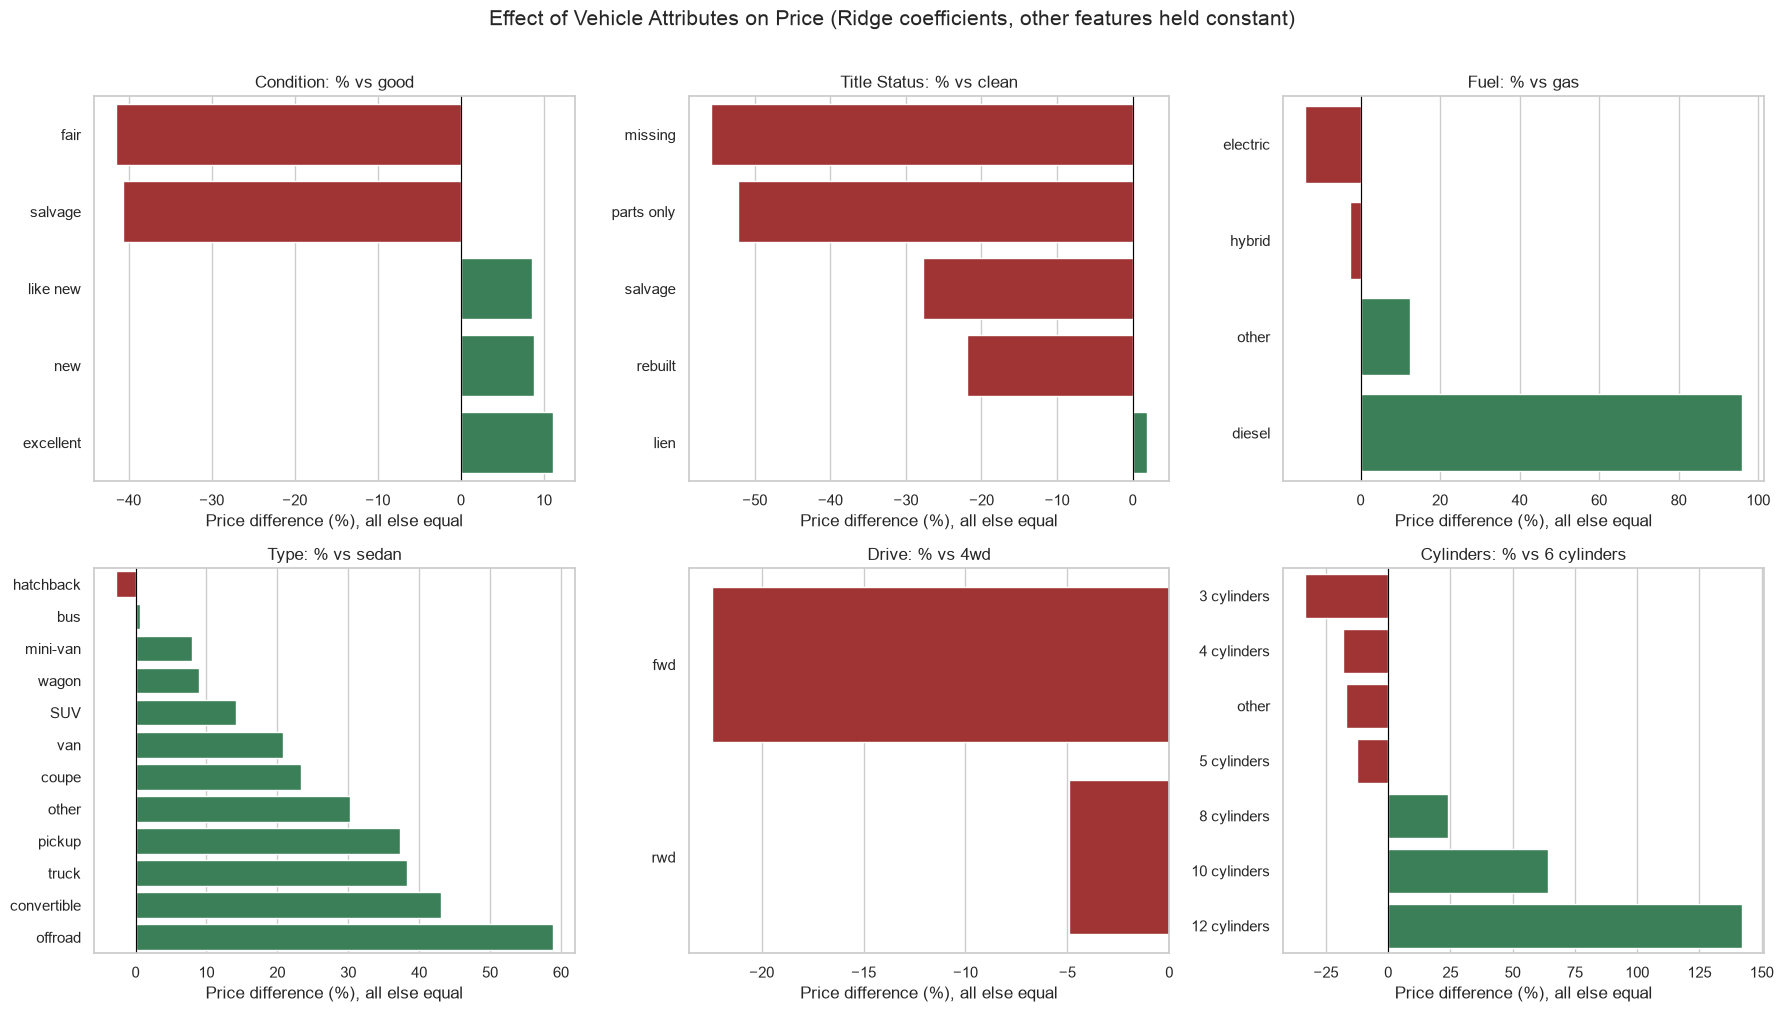

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feature in zip(axes.flat, ['condition', 'title_status', 'fuel', 'type', 'drive', 'cylinders']):
    effect = effects[feature].drop(['unknown', 'infrequent_sklearn'], errors='ignore')
    colors = ['firebrick' if v < 0 else 'seagreen' for v in effect]
    sns.barplot(x=effect.values, y=effect.index, hue=effect.index, palette=colors, legend=False, ax=ax)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{feature.replace("_", " ").title()}: {effect.name}')
    ax.set_xlabel('Price difference (%), all else equal')
    ax.set_ylabel('')
plt.suptitle('Effect of Vehicle Attributes on Price (Ridge coefficients, other features held constant)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('images/attribute_effects.png', dpi=110, bbox_inches='tight')
plt.show()

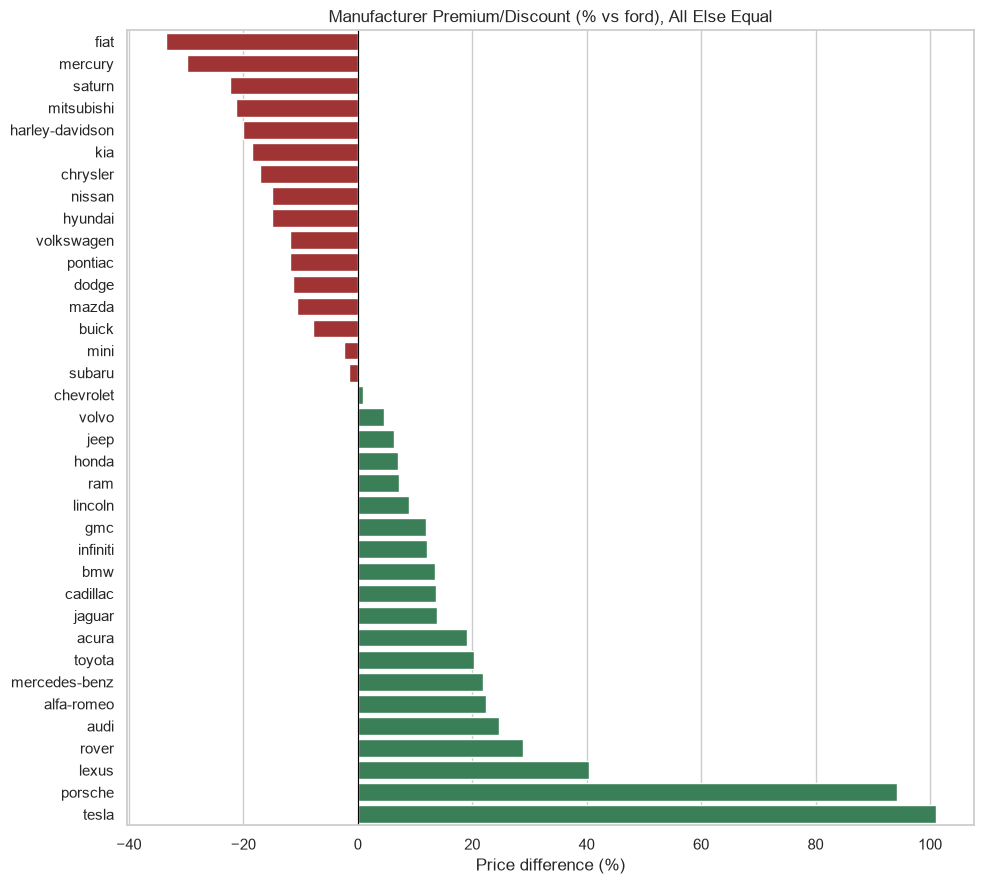

In [20]:
# Manufacturer effect relative to the most common brand (Ford)
brand_effect = effects['manufacturer'].drop(['unknown', 'infrequent_sklearn'], errors='ignore')
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(x=brand_effect.values, y=brand_effect.index, hue=brand_effect.index,
            palette=['firebrick' if v < 0 else 'seagreen' for v in brand_effect], legend=False, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Manufacturer Premium/Discount ({brand_effect.name}), All Else Equal')
ax.set_xlabel('Price difference (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Age and mileage effects

* Polynomial terms make the age and mileage coefficients hard to read directly.
* Instead, I plot the predicted price of a typical car as age or mileage changes.

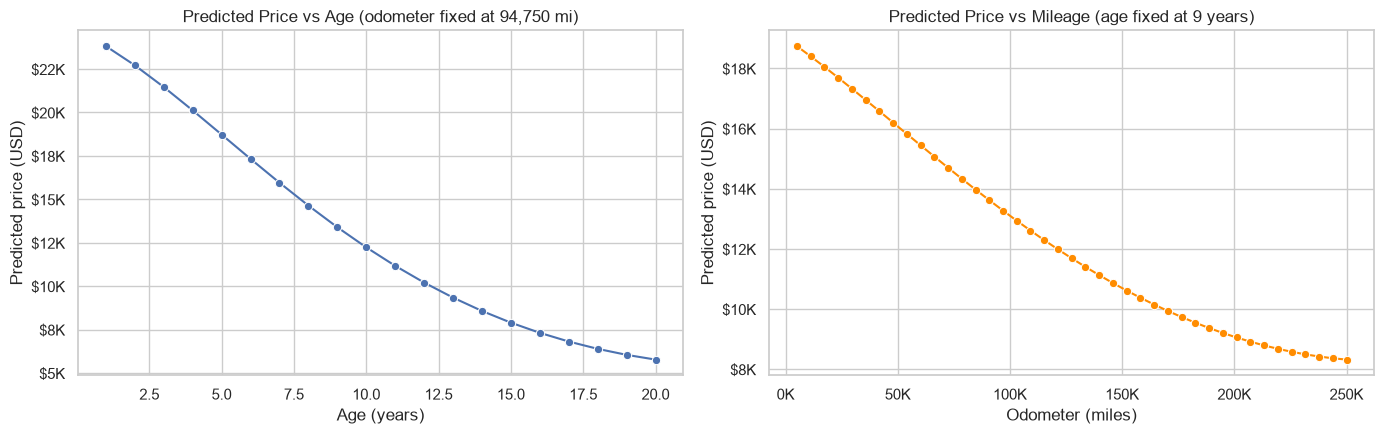

Average value lost per extra year of age (years 1-11): 7.3%
Average value lost per extra 10,000 miles (5K-100K miles): 3.7%


In [21]:
# Build a "typical" car and vary one numeric feature at a time
typical_car = {col: most_common_known(col) for col in CATEGORICAL_FEATURES}
typical_car.update({'age': int(X_train['age'].median()), 'odometer': X_train['odometer'].median()})

age_grid = pd.DataFrame([typical_car] * 20).assign(age=np.arange(1, 21))
miles_grid = pd.DataFrame([typical_car] * 41).assign(odometer=np.linspace(5_000, 250_000, 41))
age_grid['predicted_price'] = np.exp(best_model.predict(age_grid))
miles_grid['predicted_price'] = np.exp(best_model.predict(miles_grid))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=age_grid, x='age', y='predicted_price', marker='o', ax=axes[0])
axes[0].set_title(f'Predicted Price vs Age (odometer fixed at {typical_car["odometer"]:,.0f} mi)')
axes[0].set_xlabel('Age (years)')
sns.lineplot(data=miles_grid, x='odometer', y='predicted_price', marker='o', ax=axes[1], color='darkorange')
axes[1].set_title(f'Predicted Price vs Mileage (age fixed at {typical_car["age"]:.0f} years)')
axes[1].set_xlabel('Odometer (miles)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K'))
for ax in axes:
    ax.set_ylabel('Predicted price (USD)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
plt.tight_layout()
plt.show()

# Per-year and per-10K-mile depreciation around the typical car
price_at = lambda grid, col, val: grid.loc[np.isclose(grid[col], val), 'predicted_price'].iloc[0]
yearly_loss = age_grid['predicted_price'].pct_change().iloc[1:11].mean() * -100
per_10k = miles_grid['predicted_price'].pct_change().iloc[1:17].mean() * -100 * (10_000 / (miles_grid['odometer'].diff().iloc[1]))
print(f'Average value lost per extra year of age (years 1-11): {yearly_loss:.1f}%')
print(f'Average value lost per extra 10,000 miles (5K-100K miles): {per_10k:.1f}%')

### Which features matter most?

* **Permutation importance** shows how much each feature matters overall.
* I shuffle one column at a time and measure how much the RMSE gets worse.

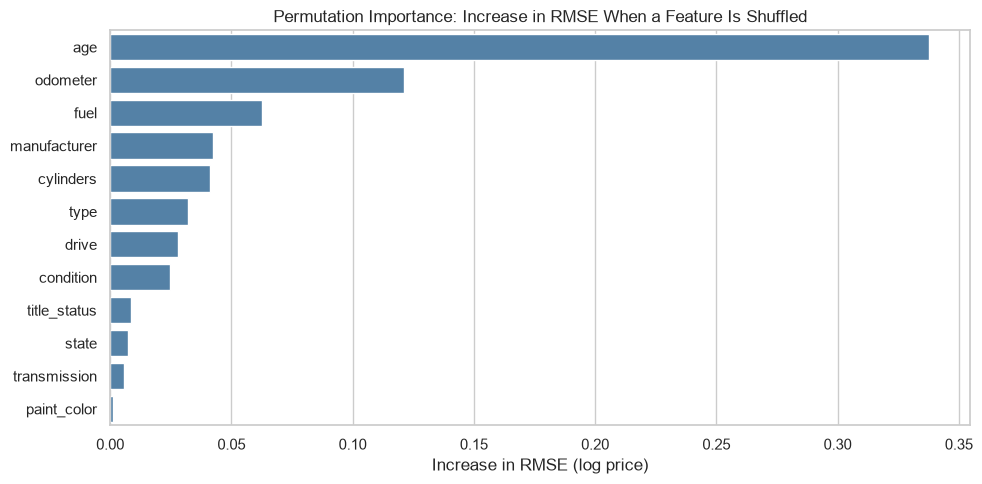

In [22]:
perm_sample = X_test.sample(20_000, random_state=RANDOM_STATE)
perm = permutation_importance(best_model, perm_sample, y_test.loc[perm_sample.index],
                              scoring='neg_root_mean_squared_error', n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=perm_sample.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index, color='steelblue', ax=ax)
ax.set_title('Permutation Importance: Increase in RMSE When a Feature Is Shuffled')
ax.set_xlabel('Increase in RMSE (log price)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()

* **Age** is the most important feature, followed by **mileage**.
* Next are fuel type, manufacturer, cylinders, body type and drivetrain.
* Condition, title status, state and transmission help a bit.
* Paint color adds almost nothing.
* Condition and title rank lower than their big coefficients suggest, because most cars have a clean title and good condition.

## 6. Findings and Recommendations

* The model explains about 78% of price differences and is off by about \$4,500 on average.
* Each effect compares cars that are otherwise the same.

### Findings

* **Age:** biggest factor. Cars lose about 7% of value per year.
* **Mileage:** about 3–4% less per extra 10,000 miles.
* **Diesel:** about 2× the price of a similar gas car.
* **Trucks and pickups:** about 37% more than sedans. FWD is about 22% less than 4WD.
* **Brand:** Toyota, Lexus, Audi, Mercedes, Porsche and Tesla sell above Ford. Kia, Nissan and Hyundai sell below.
* **Title:** rebuilt or salvage titles cost 22–28%.
* **Paint color:** almost no effect.

### Recommendations and Next Steps

* Buy newer, lower-mileage cars.
* Stock trucks, SUVs, 4WD and diesel vehicles.
* Favor premium brands, and buy budget brands only at a discount.
* Avoid salvage and rebuilt titles unless they're much cheaper.
* Don't pay extra for paint color.
* Next: add model and trim data, and retrain on recent sale prices.